### 1. 데이터 기초 특성 파악

In [ ]:
# - pandas를 이용해 데이터를 불러오고, shape, dtypes, describe()를 이용하여 데이터의 전체 구조와 기술통계량을 확인하시오.
import pandas as pd

df = pd.read_csv('prj_data_final.csv')

In [2]:
df.shape

(500, 16)

In [3]:
df.dtypes

고객ID                       str
나이                     float64
성별                         str
거주지역                       str
가입경로                       str
멤버십등급                      str
월평균구매금액                float64
구매횟수                   float64
리뷰점수                   float64
쿠폰사용여부                     str
메모                         str
이탈여부                     int64
쿠폰사용 N                    bool
쿠폰사용 Y                    bool
거주지역_label_encoding      int64
ratio                  float64
dtype: object

In [4]:
df.describe()

,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부,거주지역_label_encoding,ratio
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.180000,86092.413399,7.822000,3.736632,0.380000,2.350000,2.030421
std,14.384764,47003.366902,4.481795,0.540323,0.485873,1.496656,1.000476
min,18.000000,19127.903927,1.000000,2.500000,0.000000,0.000000,0.238095
25%,32.000000,48362.456334,4.000000,3.400000,0.000000,1.000000,1.250000
50%,43.000000,74770.324856,7.000000,3.700000,0.000000,3.000000,1.944444
75%,56.000000,114551.098353,10.250000,4.100000,1.000000,4.000000,2.666667
max,69.000000,213834.061381,21.000000,5.000000,1.000000,4.000000,5.250000


In [6]:
# - 수치형 변수와 범주형 변수를 구분하여 리스트로 정리하시오.
df_num_cols = df.select_dtypes(include='number').columns

df_cat_cols = df.select_dtypes(exclude='number').columns

print(f'수치형 {df_num_cols}')
print(f'범주형 {df_cat_cols}')

수치형 Index(['나이', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부', '거주지역_label_encoding',
       'ratio'],
      dtype='str')
범주형 Index(['고객ID', '성별', '거주지역', '가입경로', '멤버십등급', '쿠폰사용여부', '메모', '쿠폰사용 N',
       '쿠폰사용 Y'],
      dtype='str')


In [7]:
# - 범주형 변수 중 1개 이상에 대해 value_counts()로 범주별 빈도를 확인하시오.
df[df_cat_cols[2]].value_counts()

거주지역
서울    155
경기    123
대구     89
부산     80
기타     53
Name: count, dtype: int64

### 2. 단변량/분포 시각화

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='월평균구매금액', ylabel='Count'>

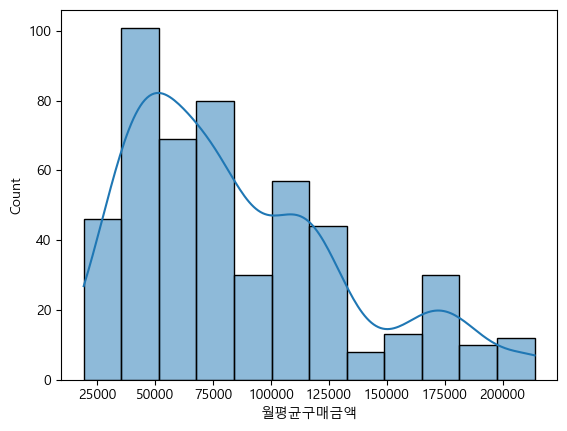

In [28]:
# - 수치형 변수 1개 이상에 대해 히스토그램(hist 또는 histplot)을 그려 분포 형태를 확인하시오.
sns.histplot(df['월평균구매금액'], kde=True)


Text(0.5, 1.0, '멤버십등급별 고객 수')

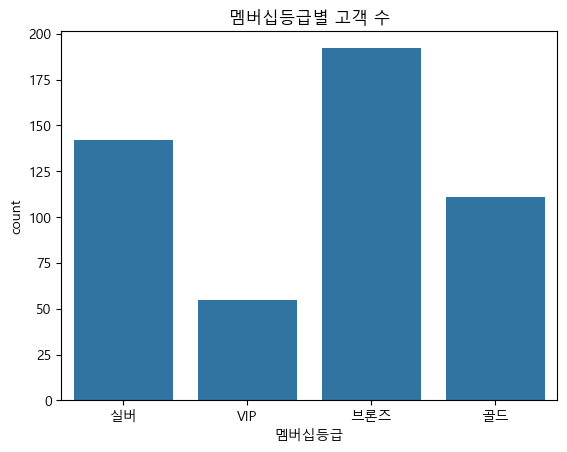

In [10]:
# - 범주형 변수 1개 이상에 대해 막대그래프(countplot)를 그려 범주별 분포를 확인하시오.
sns.countplot(data=df,x='멤버십등급')
plt.title('멤버십등급별 고객 수')


<Axes: xlabel='구매횟수', ylabel='Count'>

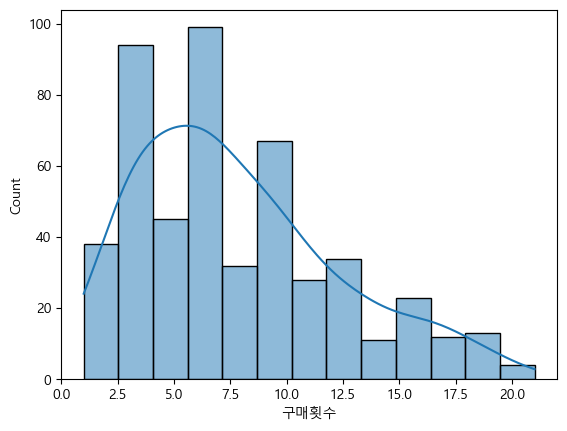

In [29]:
sns.histplot(df['구매횟수'], kde=True)

In [ ]:
# - 시각화 결과를 바탕으로 데이터의 분포 특성(치우침, 왜도, 특이 구간 등)을 1~2문장으로 해석하시오.
df['월평균구매금액'].skew().round(3)

np.float64(0.914)

월평균구매금액은 **왜도(Skewness)가 0.914로 양(+)의 왜도**를 보여 오른쪽으로 긴 꼬리를 가진 분포를 나타낸다. 대부분의 고객은 비교적 낮거나 중간 수준의 구매금액을 보이며, 일부 고객의 높은 구매금액이 분포의 오른쪽 꼬리를 형성하는 것으로 해석된다.

### 3. 상관관계 및 이변량 분석

In [13]:
import numpy as np

In [15]:
df_num_cols

Index(['나이', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부', '거주지역_label_encoding',
       'ratio'],
      dtype='str')

Text(0.5, 1.0, '월평균구매금액 vs 구매횟수')

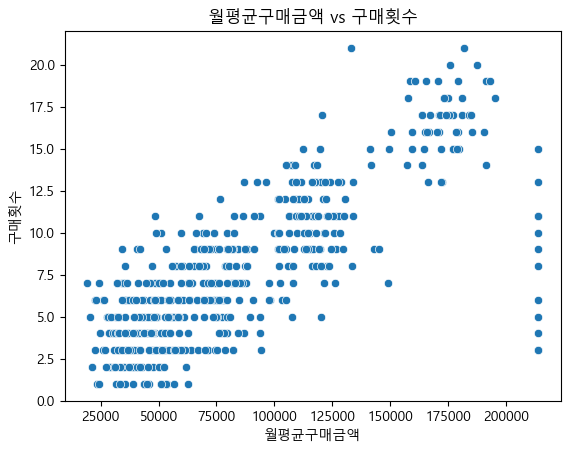

In [ ]:
# - 수치형 변수 간 상관계수 행렬을 corr()로 계산하고, heatmap으로 시각화하시오.
corr = df[['나이','월평균구매금액', '구매횟수', '리뷰점수']].corr(numeric_only=True)
corr
# - 상관관계가 가장 높은 변수 쌍 1개를 선택하여 scatterplot으로 관계를 시각화하시오.
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pair = corr_pairs.abs().sort_values(ascending=False).index[0]

sns.scatterplot(data=df, x=top_pair[0], y=top_pair[1])
plt.title(f'{top_pair[0]} vs {top_pair[1]}')



<Axes: xlabel='거주지역', ylabel='월평균구매금액'>

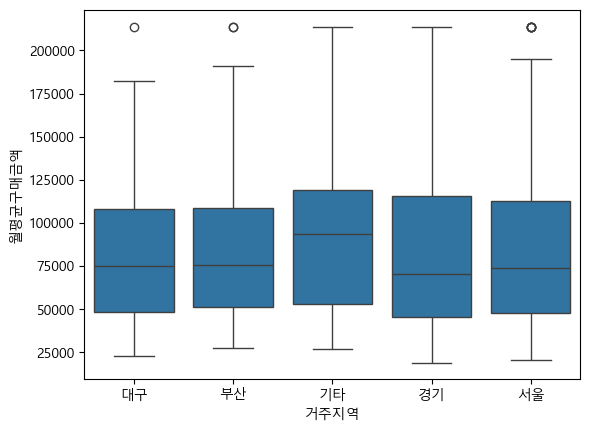

In [17]:
# - 범주형 변수와 수치형 변수 간의 관계를 boxplot 또는 그룹별 평균 비교로 시각화하시오.
sns.boxplot(data=df, x='거주지역', y='월평균구매금액')
# plt.title('흡연 여부별 의료비 분포')


Text(0.5, 1.0, '수치형 변수 상관관계')

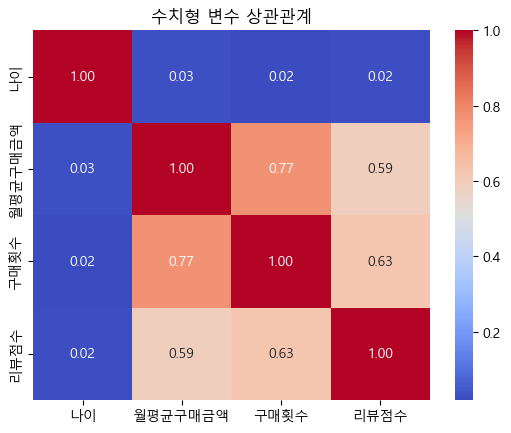

In [30]:
# 히트맵 그래프
sns.heatmap(data=corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('수치형 변수 상관관계')

In [ ]:
# - 위 결과를 바탕으로 변수 간 관계에 대한 해석을 서술하시오. (상관관계 ≠ 인과관계 언급 포함)

## 변수 간 관계 해석

상관분석 결과를 통해 변수 간의 선형적인 관계를 확인하였다.

- 월평균구매금액과 구매횟수는 양(+)의 상관관계를 보여 구매횟수가 많을수록 월평균구매금액도 증가하는 경향을 확인할 수 있었다.
- 리뷰점수와 월평균구매금액(또는 구매횟수)의 상관계수는 크지 않아 리뷰점수만으로 구매 행동을 설명하기는 어려운 것으로 나타났다.

### 4. 그룹별 비교 분석 및 인사이트 도출

In [18]:
# - 특정 범주형 변수를 기준으로 groupby() 또는 피벗테이블(pivot_table)을 이용하여 그룹별 통계량(평균, 합계 등)을 비교하시오.
g1 = df.groupby('거주지역')['월평균구매금액'].mean()
g1


거주지역
경기    83891.343361
기타    94256.710058
대구    84966.349950
부산    86450.817708
서울    85509.001747
Name: 월평균구매금액, dtype: float64

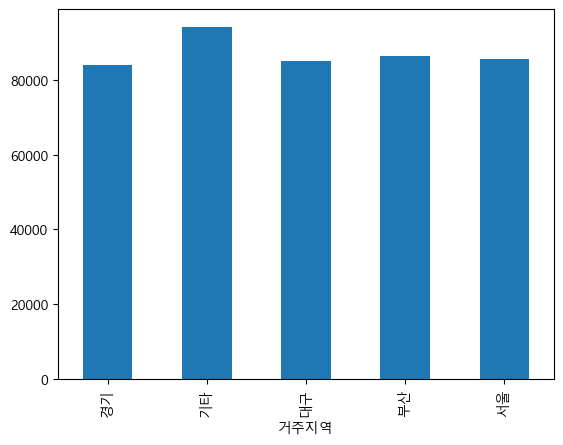

In [ ]:
# - 그룹별 비교 결과를 막대그래프 등으로 시각화하시오.
g1.plot(kind='bar')
plt.show()


In [ ]:
# - 분석 결과를 종합하여, 데이터에서 발견한 인사이트 2가지 이상을 비즈니스/업무 관점에서 서술하시오.

## 데이터 분석 인사이트

### 1. 구매횟수가 높은 고객 관리 강화

구매횟수와 구매금액이 양의 상관관계를 보인다면, 기존 고객의 재구매를 유도하는 것이 매출 증대에 효과적일 수 있다. 적립금, 멤버십, 쿠폰 제공 등의 마케팅 전략을 통해 고객의 재방문을 유도할 필요가 있다.

### 2. 리뷰 관리만으로는 구매 증가를 기대하기 어려움

리뷰점수와 구매 관련 변수의 상관관계가 낮다면, 리뷰 품질 개선만으로 구매를 크게 늘리기는 어려울 수 있다. 가격 할인, 쿠폰 제공, 맞춤형 추천 등 다양한 마케팅 전략을 함께 운영하는 것이 효과적이다.

### 3. 고객 세분화 마케팅 활용

연령, 거주지역, 구매횟수 등의 정보를 활용하여 고객을 세분화하면 지역별 또는 연령대별 맞춤형 프로모션을 제공할 수 있다. 이를 통해 마케팅 효율성과 고객 만족도를 높일 수 있다.